In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Charger les données
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_test = joblib.load('../data/y_test.pkl')
le = joblib.load('../models/label_encoder.pkl')

print("Data loaded")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data loaded
X_train shape: (2016472, 52)
X_test shape: (504118, 52)


In [9]:
from datetime import datetime
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# Apply SMOTE on FULL X_train
# ==============================
print("Applying SMOTE on full data... this will take a while !")
start = datetime.now()

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

end = datetime.now()
print(f"SMOTE time: {end - start}")
print("Original shape:", X_train.shape)
print("Balanced shape:", X_train_bal.shape)

Applying SMOTE on full data... this will take a while !
SMOTE time: 0:01:16.916911
Original shape: (2016472, 52)
Balanced shape: (11731419, 52)


In [10]:
import psutil
ram = psutil.virtual_memory()
print(f"Available RAM: {ram.available / 1024**3:.1f} GB")

Available RAM: 6.4 GB


In [11]:
# ==============================
# Train Decision Tree
# ==============================
print("Training Decision Tree...")
start = datetime.now()

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train_bal, y_train_bal)

end = datetime.now()
print(f"Training time: {end - start}")

# Predict on ORIGINAL X_test
y_pred_dt = dt.predict(X_test)

# Evaluation
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Training Decision Tree...
Training time: 0:09:52.953023

Accuracy: 98.71 %

Classification Report:
                precision    recall  f1-score   support

          Bots       0.11      0.98      0.20       389
   Brute Force       0.88      1.00      0.94      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       0.94      1.00      0.97     38749
Normal Traffic       1.00      0.98      0.99    418979
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.58      0.98      0.73       429

      accuracy                           0.99    504118
     macro avg       0.79      0.99      0.83    504118
  weighted avg       0.99      0.99      0.99    504118



In [12]:
joblib.dump(dt, '../models/decision_tree.pkl')
print("Decision Tree saved ")

Decision Tree saved 


In [13]:
from sklearn.ensemble import RandomForestClassifier

# ==============================
# Train Random Forest
# ==============================
print("Training Random Forest...")
start = datetime.now()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)
rf.fit(X_train_bal, y_train_bal)

end = datetime.now()
print(f"Training time: {end - start}")

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Training Random Forest...
Training time: 0:36:44.023761

Accuracy: 99.87 %

Classification Report:
                precision    recall  f1-score   support

          Bots       0.72      0.90      0.80       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38749
Normal Traffic       1.00      1.00      1.00    418979
 Port Scanning       0.99      0.99      0.99     18139
   Web Attacks       0.98      0.99      0.98       429

      accuracy                           1.00    504118
     macro avg       0.96      0.98      0.97    504118
  weighted avg       1.00      1.00      1.00    504118



In [14]:
joblib.dump(rf, '../models/random_forest.pkl')
print("Random Forest saved ")

Random Forest saved 


In [15]:
from xgboost import XGBClassifier

# ==============================
# Train XGBoost
# ==============================
print("Training XGBoost...")
start = datetime.now()

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb.fit(X_train_bal, y_train_bal)

end = datetime.now()
print(f"Training time: {end - start}")

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluation
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Training XGBoost...


c:\Users\chouc\anaconda3\envs\cicids\lib\site-packages\xgboost\training.py:200: UserWarning: [11:59:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time: 0:09:00.245075

Accuracy: 99.88 %

Classification Report:
                precision    recall  f1-score   support

          Bots       0.56      0.97      0.71       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38749
Normal Traffic       1.00      1.00      1.00    418979
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.97      1.00      0.98       429

      accuracy                           1.00    504118
     macro avg       0.93      1.00      0.96    504118
  weighted avg       1.00      1.00      1.00    504118



In [16]:
joblib.dump(xgb, '../models/xgboost.pkl')
print("XGBoost saved ")

XGBoost saved 


In [18]:
from lightgbm import LGBMClassifier

# ==============================
# Train LightGBM
# ==============================
print("Training LightGBM...")
start = datetime.now()

lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # suppress warnings
)
lgbm.fit(X_train_bal, y_train_bal)

end = datetime.now()
print(f"Training time: {end - start}")

# Predict
y_pred_lgbm = lgbm.predict(X_test)

# Evaluation
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_lgbm) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

Training LightGBM...
Training time: 0:08:04.956913


c:\Users\chouc\anaconda3\envs\cicids\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy: 97.29 %

Classification Report:
                precision    recall  f1-score   support

          Bots       0.23      0.94      0.38       389
   Brute Force       0.86      0.95      0.90      1830
          DDoS       0.95      0.99      0.97     25603
           DoS       0.95      0.99      0.97     38749
Normal Traffic       1.00      0.97      0.98    418979
 Port Scanning       0.69      1.00      0.82     18139
   Web Attacks       0.68      0.98      0.80       429

      accuracy                           0.97    504118
     macro avg       0.77      0.97      0.83    504118
  weighted avg       0.98      0.97      0.98    504118



In [19]:
joblib.dump(lgbm, '../models/lightgbm.pkl')
print("LightGBM saved ")

LightGBM saved 


In [20]:
# Overfitting check for all models
models = {
    'Decision Tree': (dt, y_pred_dt),
    'Random Forest': (rf, y_pred_rf),
    'XGBoost': (xgb, y_pred_xgb),
    'LightGBM': (lgbm, y_pred_lgbm),
}

print("=" * 55)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Diff':>10}")
print("=" * 55)

for name, (model, y_pred_test) in models.items():
    train_acc = round(accuracy_score(y_train_bal, model.predict(X_train_bal)) * 100, 2)
    test_acc = round(accuracy_score(y_test, y_pred_test) * 100, 2)
    diff = round(train_acc - test_acc, 2)
    print(f"{name:<20} {train_acc:>10} {test_acc:>10} {diff:>10}")

print("=" * 55)

Model                 Train Acc   Test Acc       Diff
Decision Tree             99.51      98.71        0.8
Random Forest             100.0      99.87       0.13
XGBoost                   99.98      99.88        0.1


c:\Users\chouc\anaconda3\envs\cicids\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                  98.91      97.29       1.62


        Model  Accuracy  Train Accuracy  Overfitting Diff Training Time
Decision Tree     98.71           99.51              0.80         9 min
Random Forest     99.87          100.00              0.13        36 min
      XGBoost     99.88           99.98              0.10         9 min
     LightGBM     97.29           98.91              1.62         8 min


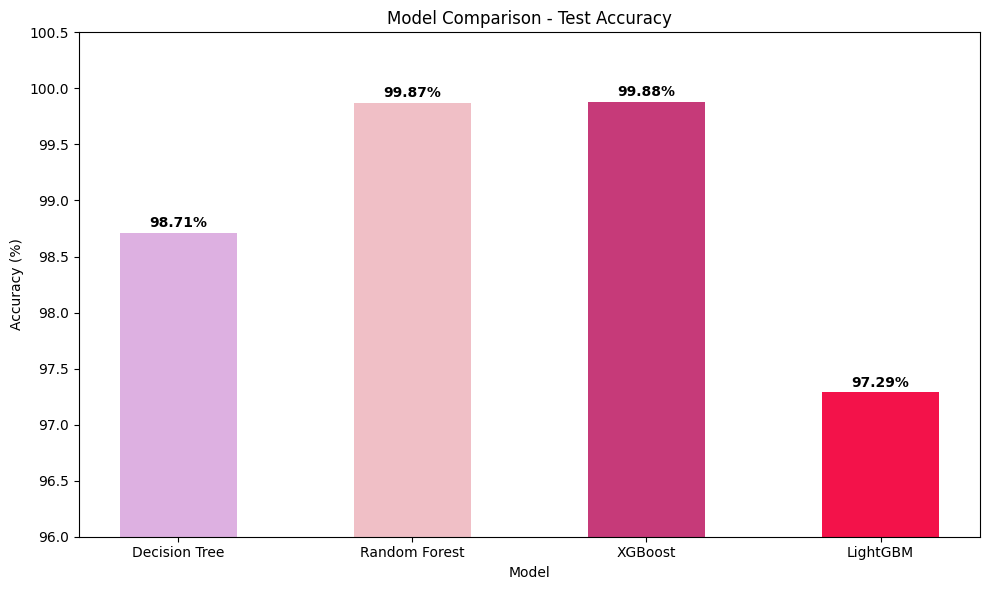

In [22]:

# Final Comparison Table

import pandas as pd

results = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [98.71, 99.87, 99.88, 97.29],
    'Train Accuracy': [99.51, 100.0, 99.98, 98.91],
    'Overfitting Diff': [0.8, 0.13, 0.1, 1.62],
    'Training Time': ['9 min', '36 min', '9 min', '8 min'],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


# Visualize comparison

import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']
accuracies = [98.71, 99.87, 99.88, 97.29]
colors = ["#ddb0e1", "#f0bfc6", "#c63a79", "#f3124a"]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(96, 100.5)
plt.title('Model Comparison - Test Accuracy')
plt.ylabel('Accuracy (%)')
plt.xlabel('Model')

# Add values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.05,
             f'{acc}%', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import f1_score

# F1 per class for each model
f1_dt = f1_score(y_test, y_pred_dt, average=None)
f1_rf = f1_score(y_test, y_pred_rf, average=None)
f1_xgb = f1_score(y_test, y_pred_xgb, average=None)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average=None)

df_f1 = pd.DataFrame({
    'Class': le.classes_,
    'Decision Tree': f1_dt.round(2),
    'Random Forest': f1_rf.round(2),
    'XGBoost': f1_xgb.round(2),
    'LightGBM': f1_lgbm.round(2)
})

print(df_f1.to_string(index=False))

         Class  Decision Tree  Random Forest  XGBoost  LightGBM
          Bots           0.20           0.80     0.71      0.38
   Brute Force           0.94           1.00     1.00      0.90
          DDoS           1.00           1.00     1.00      0.97
           DoS           0.97           1.00     1.00      0.97
Normal Traffic           0.99           1.00     1.00      0.98
 Port Scanning           0.99           0.99     0.99      0.82
   Web Attacks           0.73           0.98     0.98      0.80


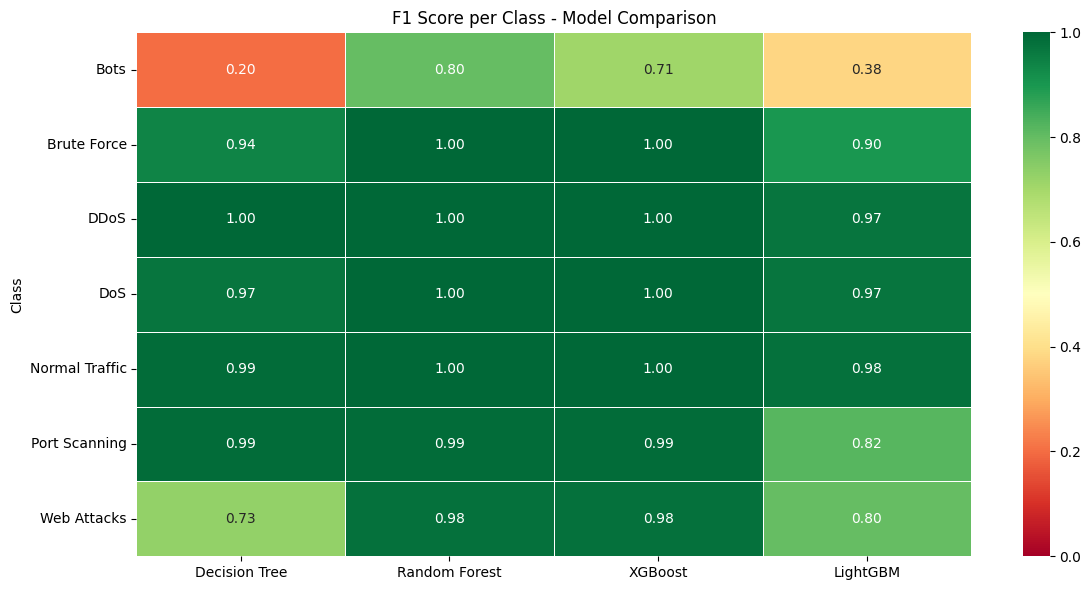

In [24]:
# F1 comparison heatmap
plt.figure(figsize=(12, 6))
df_f1_plot = df_f1.set_index('Class')
sns.heatmap(df_f1_plot, annot=True, fmt='.2f', 
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5)
plt.title('F1 Score per Class - Model Comparison')
plt.tight_layout()
plt.show()

In [25]:
joblib.dump(xgb, '../models/best_model.pkl')
print("Best model saved ")

Best model saved 


In [2]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import joblib
import mlflow
mlflow.set_tracking_uri("../mlruns")
# Configurer MLflow
mlflow.set_experiment("CICIDS2017_Classification")

# Charger les données
X_test = joblib.load('../data/X_test.pkl')
y_test = joblib.load('../data/y_test.pkl')

# Modèles à logger
models = {
    'Decision Tree': '../models/decision_tree.pkl',
    'Random Forest': '../models/random_forest.pkl',
    'XGBoost': '../models/xgboost.pkl',
    'LightGBM': '../models/lightgbm.pkl'
}

for model_name, model_path in models.items():
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)
    
    with mlflow.start_run(run_name=model_name):
        # Logger les métriques
        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("f1_macro", f1_score(y_test, y_pred, average='macro'))
        mlflow.log_metric("precision", precision_score(y_test, y_pred, average='macro'))
        mlflow.log_metric("recall", recall_score(y_test, y_pred, average='macro'))
        
        # Logger les paramètres
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("dataset", "CICIDS2017")
        mlflow.log_param("smote", True)
        
        # Logger le modèle
        mlflow.sklearn.log_model(model, model_name)
        
        print(f"{model_name} loggé dans MLflow")

print("\nTous les modèles sont dans MLflow !")

2026/06/12 08:33:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 08:33:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Decision Tree loggé dans MLflow


2026/06/12 08:33:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 08:33:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest loggé dans MLflow


2026/06/12 08:33:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 08:33:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
c:\Users\chouc\anaconda3\envs\cicids\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


XGBoost loggé dans MLflow


2026/06/12 08:33:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/12 08:33:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM loggé dans MLflow

Tous les modèles sont dans MLflow !
